In [419]:
import pyomo.environ as pyo
from pyomo.gdp import Disjunction, Disjunct
import json
import os

In [420]:
def build_rect_strip_packing_model_modified():
    # # Get the absolute path of the current directory
    # script_dir = os.path.dirname(os.path.abspath(__file__))
    # Use current working directory in Jupyter
    script_dir = os.getcwd()

    # Construct the path to the JSON file, Modify the path number for different scheduling data
    json_file_path = os.path.abspath(
        os.path.join(script_dir, "..", "packing_data", "strip_packing_rectangle_4.json")
    )

    with open(json_file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    strip_width = data["strip_width"]
    rec_ids     = [rec["index"] for rec in data["rectangles"]]
    widths      = {rec["index"]: rec["width"]  for rec in data["rectangles"]}
    lengths     = {rec["index"]: rec["length"] for rec in data["rectangles"]}

    # Create a concrete model
    m = pyo.ConcreteModel(name="Rectangles strip packing")

    # sets & parameters
    m.rectangles   = pyo.Set(initialize=rec_ids, ordered=True) # Set of rectangles
    m.rect_width   = pyo.Param(m.rectangles, initialize=widths) # Width of each rectangle
    m.rect_length  = pyo.Param(m.rectangles, initialize=lengths) # Length of each rectangle
    m.strip_width  = pyo.Param(initialize=strip_width) # Available width of the strip
    
    # upperbound on length (default is sum of lengths of rectangles)
    m.max_length = pyo.Param(
        initialize=sum(lengths.values()),
        doc="Loose upper bound on total strip length",
    )

    # x (length) and y (width) coordinates of each of the rectangles
    def x_bounds(m, i):
    # allow x[i] as far as max_length - its own length
        return (0, m.max_length - m.rect_length[i])

    m.x = pyo.Var(
        m.rectangles,
        bounds=x_bounds,
        doc="rectangle corner x-position (position down length)",
    )
    
    def w_bounds(m, i):
        return (m.rect_width[i], m.strip_width)

    m.y = pyo.Var(
        m.rectangles,
        bounds=w_bounds,
        doc="rectangle corner y-position (position across width)",
    )

    m.strip_length = pyo.Var(within=pyo.NonNegativeReals, doc="Length of strip required.")

    def rec_pairs_filter(m, i, j):
        return i < j
    
    m.overlap_pairs = pyo.Set(
        initialize=m.rectangles * m.rectangles,
        dimen=2,
        filter=rec_pairs_filter,
        doc="set of possible rectangle conflicts",
    )

    # Constraints
    @m.Constraint(m.rectangles)
    def strip_ends_after_last_rec(m, i):
        return m.strip_length >= m.x[i] + m.rect_length[i]

    # Objective
    m.total_length = pyo.Objective(expr=m.strip_length, doc="Minimize length")

    # Disjuncts for overlap conditions
    def i_before_j_rule(disjunct, i, j):
        m = disjunct.model()
        disjunct.cons = pyo.ConstraintList()
        disjunct.cons.add(m.x[i] + m.rect_length[i] <= m.x[j])
    m.i_before_j = Disjunct(m.overlap_pairs, rule=i_before_j_rule)

    def j_before_i_rule(disjunct, i, j):
        m = disjunct.model()
        disjunct.cons = pyo.ConstraintList()
        disjunct.cons.add(m.x[j] + m.rect_length[j] <= m.x[i])
    m.j_before_i = Disjunct(m.overlap_pairs, rule=j_before_i_rule)

    def i_above_j_rule(disjunct, i, j):
        m = disjunct.model()
        disjunct.cons = pyo.ConstraintList()
        disjunct.cons.add(m.y[i] - m.rect_width[i] >= m.y[j]) 
    m.i_above_j = Disjunct(m.overlap_pairs, rule=i_above_j_rule)

    def j_above_i_rule(disjunct, i, j):
        m = disjunct.model()
        disjunct.cons = pyo.ConstraintList()
        disjunct.cons.add(m.y[j] - m.rect_width[j] >= m.y[i]) 
    m.j_above_i = Disjunct(m.overlap_pairs, rule=j_above_i_rule)

    # Disjunction across all four disjuncts
    def no_overlap_disjunction_rule(m, i, j):
        return [
            m.i_before_j[i, j],
            m.j_before_i[i, j],
            m.i_above_j[i, j],
            m.j_above_i[i, j],
        ]
    
    m.no_overlap = Disjunction(m.overlap_pairs, rule=no_overlap_disjunction_rule)

    return m

In [421]:
# Build the strip packing model containing the bounds of the width and length of the rectangles
def build_rect_strip_packing_model_altered():
    # # Get the absolute path of the current directory
    # script_dir = os.path.dirname(os.path.abspath(__file__))
    # Use current working directory in Jupyter
    script_dir = os.getcwd()

    # Construct the path to the JSON file, Modify the path number for different scheduling data
    json_file_path = os.path.abspath(
        os.path.join(script_dir, "..", "packing_data", "strip_packing_rectangle_4.json")
    )

    with open(json_file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    strip_width = data["strip_width"]
    rec_ids     = [rec["index"] for rec in data["rectangles"]]
    widths      = {rec["index"]: rec["width"]  for rec in data["rectangles"]}
    lengths     = {rec["index"]: rec["length"] for rec in data["rectangles"]}

    # Create a concrete model
    m = pyo.ConcreteModel(name="Rectangles strip packing")

    # sets & parameters
    m.rectangles   = pyo.Set(initialize=rec_ids, ordered=True) # Set of rectangles
    m.rect_width   = pyo.Param(m.rectangles, initialize=widths) # Width of each rectangle
    m.rect_length  = pyo.Param(m.rectangles, initialize=lengths) # Length of each rectangle
    m.strip_width  = pyo.Param(initialize=strip_width) # Available width of the strip
    
    # upperbound on length (default is sum of lengths of rectangles)
    m.max_length = pyo.Param(
        initialize=sum(lengths.values()),
        doc="Loose upper bound on total strip length",
    )

    # x (length) and y (width) coordinates of each of the rectangles
    def x_bounds(m, i):
    # allow x[i] as far as max_length - its own length
        return (0, m.max_length)

    m.x = pyo.Var(
        m.rectangles,
        bounds=x_bounds,
        doc="rectangle corner x-position (position down length)",
    )
    
    def w_bounds(m, i):
        return (m.rect_width[i], m.strip_width)

    m.y = pyo.Var(
        m.rectangles,
        bounds=w_bounds,
        doc="rectangle corner y-position (position across width)",
    )

    m.strip_length = pyo.Var(within=pyo.NonNegativeReals, doc="Length of strip required.")

    def rec_pairs_filter(m, i, j):
        return i < j
    
    m.overlap_pairs = pyo.Set(
        initialize=m.rectangles * m.rectangles,
        dimen=2,
        filter=rec_pairs_filter,
        doc="set of possible rectangle conflicts",
    )

    # Constraints
    @m.Constraint(m.rectangles)
    def strip_ends_after_last_rec(m, i):
        return m.strip_length >= m.x[i] + m.rect_length[i]

    # Objective
    m.total_length = pyo.Objective(expr=m.strip_length, doc="Minimize length")

    # Disjuncts for overlap conditions
    def i_before_j_rule(disjunct, i, j):
        m = disjunct.model()
        disjunct.cons = pyo.ConstraintList()
        disjunct.cons.add(m.x[i] + m.rect_length[i] <= m.x[j])
        disjunct.cons.add(m.y[i] - m.y[j] <= m.strip_width - m.rect_width[j])
        disjunct.cons.add(m.rect_width[i] - m.strip_width <= m.y[i] - m.y[j])
    m.i_before_j = Disjunct(m.overlap_pairs, rule=i_before_j_rule)

    def j_before_i_rule(disjunct, i, j):
        m = disjunct.model()
        disjunct.cons = pyo.ConstraintList()
        disjunct.cons.add(m.x[j] + m.rect_length[j] <= m.x[i])
        disjunct.cons.add(m.y[i] - m.y[j] <= m.strip_width - m.rect_width[j])
        disjunct.cons.add(m.rect_width[i] - m.strip_width <= m.y[i] - m.y[j])
    m.j_before_i = Disjunct(m.overlap_pairs, rule=j_before_i_rule)

    def i_above_j_rule(disjunct, i, j):
        m = disjunct.model()
        disjunct.cons = pyo.ConstraintList()
        disjunct.cons.add(m.y[i] - m.rect_width[i] >= m.y[j])
        disjunct.cons.add(m.x[j] + m.max_length >= m.x[i])
        disjunct.cons.add(m.x[i] + m.max_length >= m.x[j])
    m.i_above_j = Disjunct(m.overlap_pairs, rule=i_above_j_rule)

    def j_above_i_rule(disjunct, i, j):
        m = disjunct.model()
        disjunct.cons = pyo.ConstraintList()
        disjunct.cons.add(m.y[j] - m.rect_width[j] >= m.y[i])
        disjunct.cons.add(m.x[j] + m.max_length >= m.x[i])
        disjunct.cons.add(m.x[i] + m.max_length >= m.x[j])
    m.j_above_i = Disjunct(m.overlap_pairs, rule=j_above_i_rule)

    # Disjunction across all four disjuncts
    def no_overlap_disjunction_rule(m, i, j):
        return [
            m.i_before_j[i, j],
            m.j_before_i[i, j],
            m.i_above_j[i, j],
            m.j_above_i[i, j],
        ]
    
    m.no_overlap = Disjunction(m.overlap_pairs, rule=no_overlap_disjunction_rule)

    return m



# m = build_rect_strip_packing_model_altered()

In [422]:
# Build the reaggregated Hull Reformulation
def build_rect_strip_packing_model_reagg():
    # # Get the absolute path of the current directory
    # script_dir = os.path.dirname(os.path.abspath(__file__))
    # Use current working directory in Jupyter
    script_dir = os.getcwd()

    # Construct the path to the JSON file, Modify the path number for different scheduling data
    json_file_path = os.path.abspath(
        os.path.join(script_dir, "..", "packing_data", "strip_packing_rectangle_4.json")
    )

    with open(json_file_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    strip_width = data["strip_width"]
    rec_ids     = [rec["index"] for rec in data["rectangles"]]
    widths      = {rec["index"]: rec["width"]  for rec in data["rectangles"]}
    lengths     = {rec["index"]: rec["length"] for rec in data["rectangles"]}

    # Create a concrete model
    m = pyo.ConcreteModel(name="Rectangles strip packing")

    # sets & parameters
    m.rectangles   = pyo.Set(initialize=rec_ids, ordered=True) # Set of rectangles
    m.rect_width   = pyo.Param(m.rectangles, initialize=widths) # Width of each rectangle
    m.rect_length  = pyo.Param(m.rectangles, initialize=lengths) # Length of each rectangle
    m.strip_width  = pyo.Param(initialize=strip_width) # Available width of the strip
    
    # upperbound on length (default is sum of lengths of rectangles)
    m.max_length = pyo.Param(
        initialize=sum(lengths.values()),
        doc="Loose upper bound on total strip length",
    )

    # x (length) and y (width) coordinates of each of the rectangles
    def x_bounds(m, i):
    # allow x[i] as far as max_length - its own length
        return (0, m.max_length - m.rect_length[i])

    m.x = pyo.Var(
        m.rectangles,
        bounds=x_bounds,
        doc="rectangle corner x-position (position down length)",
    )
    
    def w_bounds(m, i):
        return (m.rect_width[i], m.strip_width)

    m.y = pyo.Var(
        m.rectangles,
        bounds=w_bounds,
        doc="rectangle corner y-position (position across width)",
    )

    m.strip_length = pyo.Var(within=pyo.NonNegativeReals, doc="Length of strip required.")

    def rec_pairs_filter(m, i, j):
        return i < j
    
    m.overlap_pairs = pyo.Set(
        initialize=m.rectangles * m.rectangles,
        dimen=2,
        filter=rec_pairs_filter,
        doc="set of possible rectangle conflicts",
    )

    # Constraints
    @m.Constraint(m.rectangles)
    def strip_ends_after_last_rec(m, i):
        return m.strip_length >= m.x[i] + m.rect_length[i]

    # Objective
    m.total_length = pyo.Objective(expr=m.strip_length, doc="Minimize length")

    # binary variables 
    m.yij1 = pyo.Var(m.overlap_pairs, within=pyo.Binary)
    m.yji1 = pyo.Var(m.overlap_pairs, within=pyo.Binary)
    m.yij2 = pyo.Var(m.overlap_pairs, within=pyo.Binary)
    m.yji2 = pyo.Var(m.overlap_pairs, within=pyo.Binary)
    
    def no_overlap_constraint_rule(m, i, j): 
        return m.yij1[i, j] + m.yji1[i, j] + m.yij2[i, j] + m.yji2[i, j] == 1
    m.no_overlap_constraint = pyo.Constraint(m.overlap_pairs, rule=no_overlap_constraint_rule)

    # Re-aggregated constraints
    def i_before_j_rule1(m, i, j):
        return m.x[i] - m.x[j] <= - m.rect_length[i] * m.yij1[i, j] + (m.max_length - m.rect_length[i]) * m.yji1[i, j] + (m.max_length - m.rect_length[i]) * m.yij2[i, j] + (m.max_length - m.rect_length[i]) * m.yji2[i,j]
    m.i_before_j_rule1 = pyo.Constraint(m.overlap_pairs, rule=i_before_j_rule1)

    def i_before_j_rule2(m, i, j):
        return m.x[i] - m.x[j] >= m.rect_length[j] * m.yji1[i, j] - (m.max_length - m.rect_length[j]) * m.yij1[i, j] - (m.max_length - m.rect_length[j]) * m.yij2[i, j] - (m.max_length - m.rect_length[j]) * m.yji2[i,j]
    m.i_before_j_rule2 = pyo.Constraint(m.overlap_pairs, rule=i_before_j_rule2)
    
    def i_before_j_rule3(m, i, j):
        return m.y[i] - m.y[j] <= - m.rect_width[j] * m.yji2[i, j] + (m.strip_width - m.rect_width[j]) * m.yij1[i, j] + (m.strip_width - m.rect_width[j]) * m.yji1[i, j] + (m.strip_width - m.rect_width[j]) * m.yij2[i, j]
    m.i_before_j_rule3 = pyo.Constraint(m.overlap_pairs, rule=i_before_j_rule3)

    def i_before_j_rule4(m, i, j):
        return m.y[i] - m.y[j] >= m.rect_width[i] * m.yij2[i, j] - (m.strip_width - m.rect_width[i]) * m.yij1[i, j] - (m.strip_width - m.rect_width[i]) * m.yji1[i, j] - (m.strip_width - m.rect_width[i]) * m.yji2[i, j]
    m.i_before_j_rule4 = pyo.Constraint(m.overlap_pairs, rule=i_before_j_rule4)
    
    return m

In [423]:
model = build_rect_strip_packing_model_modified()
model = build_rect_strip_packing_model_altered()
model = build_rect_strip_packing_model_reagg()
# Transform the model to a mixed-integer programming (MIP) model
pyo.TransformationFactory('gdp.bigm').apply_to(model) # hull reformulation

# Solve the model
solver = pyo.SolverFactory("gurobi")
results = solver.solve(model, tee=True)

# print the indices of rectangles and there locations
for i in model.rectangles:
    print(f"Rectangle {i}: x = {model.x[i].value}, y = {model.y[i].value}")
# print the total length of the strip
print(f"Total length of the strip: {model.strip_length.value}")

Read LP format model from file /tmp/tmpjhtyy_ps.pyomo.lp
Reading time = 0.03 seconds
x1: 34 rows, 33 columns, 176 nonzeros
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (linux64 - "Ubuntu 22.04.3 LTS")

CPU model: 12th Gen Intel(R) Core(TM) i7-1265U, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 34 rows, 33 columns and 176 nonzeros
Model fingerprint: 0xa0ae0201
Variable types: 9 continuous, 24 integer (24 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 2e+01]
  RHS range        [1e+00, 8e+00]
Found heuristic solution: objective 19.0000000
Presolve time: 0.00s
Presolved: 34 rows, 33 columns, 146 nonzeros
Variable types: 9 continuous, 24 integer (24 binary)

Root relaxation: objective 8.000000e+00, 12 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Exp

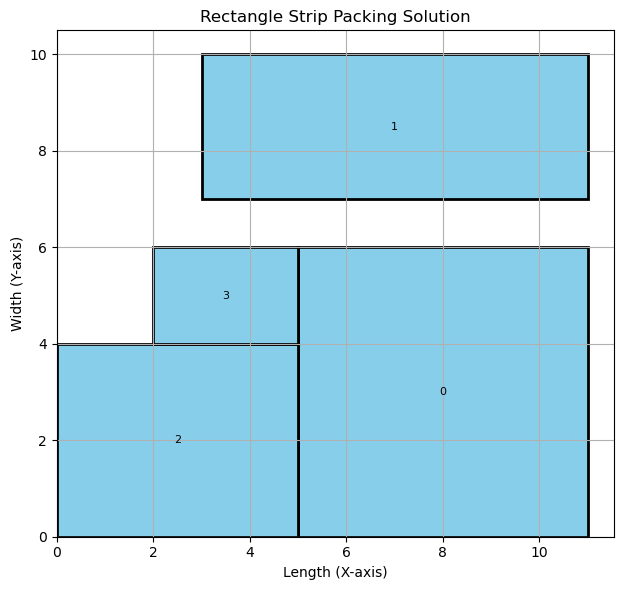

In [424]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def plot_packing_solution(model):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i in model.rectangles:
        x     = pyo.value(model.x[i])
        y_top = pyo.value(model.y[i])
        w     = pyo.value(model.rect_width[i])   # “height” in the plot
        h     = pyo.value(model.rect_length[i])  # “width”  in the plot

        # compute the bottom‐left y
        y_bot = y_top - w

        # draw rectangle with bottom‐left at (x, y_bot)
        rect = Rectangle(
            (x, y_bot),    # bottom‐left corner
            h,             # length along x
            w,             # width  along y
            edgecolor='black',
            facecolor='skyblue',
            lw=2
        )
        ax.add_patch(rect)
        ax.text(
            x + h/2,
            y_bot + w/2,
            f'{i}',
            ha='center',
            va='center',
            fontsize=8,
            color='black'
        )

    # axes limits
    ax.set_xlim(0, pyo.value(model.strip_length) * 1.05)
    ax.set_ylim(0, pyo.value(model.strip_width)  * 1.05)
    ax.set_xlabel("Length (X-axis)")
    ax.set_ylabel("Width (Y-axis)")
    ax.set_title("Rectangle Strip Packing Solution")
    ax.set_aspect('equal')
    ax.grid(True)
    plt.tight_layout()
    plt.show()

# Call the plotting function
plot_packing_solution(model)
